In [12]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt 
import seaborn as sns

#Chamando o Arquivo do kaggle baixado.
path = "data/raw/kag_risk_factors_cervical_cancer.csv"

#Criando o Banco de Dados com Pandas


<h3><b>Checando a tabela

In [13]:

df_raw = pd.read_csv(path)
df = df_raw.copy()

#Verificando as propriedades do banco de dado Originais
print(df.shape) #Ver Linhas e Colunas
print(df.head(10)) #Verificar os 10 primeiros elementos
print(df.describe()) 
print(df.info()) #Informações da tabela

(858, 36)
   Age Number of sexual partners First sexual intercourse Num of pregnancies  \
0   18                       4.0                     15.0                1.0   
1   15                       1.0                     14.0                1.0   
2   34                       1.0                        ?                1.0   
3   52                       5.0                     16.0                4.0   
4   46                       3.0                     21.0                4.0   
5   42                       3.0                     23.0                2.0   
6   51                       3.0                     17.0                6.0   
7   26                       1.0                     26.0                3.0   
8   45                       1.0                     20.0                5.0   
9   44                       3.0                     15.0                  ?   

  Smokes Smokes (years) Smokes (packs/year) Hormonal Contraceptives  \
0    0.0            0.0               

<h3><b>Verificando Elementos Vazios<b><h3>

In [14]:
valores_faltando = df.isnull().sum()
print(valores_faltando) #Não Existe valores faltando no banco de dados

Age                                   0
Number of sexual partners             0
First sexual intercourse              0
Num of pregnancies                    0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
Hormonal Contraceptives               0
Hormonal Contraceptives (years)       0
IUD                                   0
IUD (years)                           0
STDs                                  0
STDs (number)                         0
STDs:condylomatosis                   0
STDs:cervical condylomatosis          0
STDs:vaginal condylomatosis           0
STDs:vulvo-perineal condylomatosis    0
STDs:syphilis                         0
STDs:pelvic inflammatory disease      0
STDs:genital herpes                   0
STDs:molluscum contagiosum            0
STDs:AIDS                             0
STDs:HIV                              0
STDs:Hepatitis B                      0
STDs:HPV                              0


In [15]:
valores_interrogacao = (df == "?").sum()
print(valores_interrogacao) #Verificando quantos valores  "?" estão no banco de dados

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

In [16]:
#Substituindo os valores "?" for Nan(Not a Number)
def changed_question_values(df):
    df = df.replace("?", np.nan)
    return df

df = changed_question_values(df_raw)
print(df.isna().mean()*100)

Age                                    0.000000
Number of sexual partners              3.030303
First sexual intercourse               0.815851
Num of pregnancies                     6.526807
Smokes                                 1.515152
Smokes (years)                         1.515152
Smokes (packs/year)                    1.515152
Hormonal Contraceptives               12.587413
Hormonal Contraceptives (years)       12.587413
IUD                                   13.636364
IUD (years)                           13.636364
STDs                                  12.237762
STDs (number)                         12.237762
STDs:condylomatosis                   12.237762
STDs:cervical condylomatosis          12.237762
STDs:vaginal condylomatosis           12.237762
STDs:vulvo-perineal condylomatosis    12.237762
STDs:syphilis                         12.237762
STDs:pelvic inflammatory disease      12.237762
STDs:genital herpes                   12.237762
STDs:molluscum contagiosum            12

<h3><b>Verificando Duplicatas

In [17]:
#print(df[df.duplicated()]) #Vendo as duplicatas
#duplicatas_exatas = df.duplicated()

#display(df[duplicatas_exatas]) #Exibindo as duplicatas

def droping_duplicates(df):
    total_duplicatas = df.duplicated().sum() #Verificando o total de duplicatas (23 duplicatas encontradas)
    print(f"Numbers of Duplicates Removed {total_duplicatas}")
    df = df.drop_duplicates() #removendo as Duplicatas
    return df

df = droping_duplicates(df)

print(df.shape)

Numbers of Duplicates Removed 23
(835, 36)


<h3><b>Removendo as Colunas e Linhas com 50%+ faltando

In [18]:
def remove_missing_values(df):
    limite_linhas = len(df.columns) * 0.5 #Metade dos elementos faltando na linha
    limite_coluna = len(df) * 0.5
    #print(df.shape)

    print(df.shape)

    rows_before = df.shape[0]
    coluns_before = df.shape[1]

    numbers_columns_before = len(df.columns)
    #["STDs: Time since first diagnosis","STDs: Time since last diagnosis"] REMOVIDAS
    #Deletando as Colunas com 50% mais de dados faltando
    df = df.dropna(axis=1,thresh=limite_coluna)

    #Deleta as linhas com metade dos elementos faltando
    df = df.dropna(thresh=limite_linhas)

    rows_after = df.shape[0]
    coluns_after = df.shape[1]

    print(f"Columns removed: {coluns_before - coluns_after}")
    print(f"Rows removed: {rows_before - rows_after}")

    return df

df = remove_missing_values(df)

print(df.shape)


(835, 36)
Columns removed: 2
Rows removed: 93
(742, 34)


<h3><b>Imputando Dados faltando

In [19]:
def imput_missing_values(df):
    #Tenho apenas valores numéricos, utilizar a Mediana será mais adequado para substituir os valores faltando
    #Colunas listadas como objetos, trará problema na imputação
    #print(df.info())

    #Criação do imputer com Mediana como Objetivo
    num_imputer = SimpleImputer(strategy='median')

    #Havia muitas colunas sendo Object, traria problemas, precisei converter elas para numéricas
    #O pd.to_numeric checa se cada coluna é um número ou n, etenta converter para float 
    df_preenchido = df.apply(pd.to_numeric, errors='coerce')

    #Colunas com dados faltando
    colunas_faltando = [
        'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 
        'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 
        'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 
        'IUD (years)', 'STDs', 'STDs (number)', 
        'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 
        'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 
        'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 
        'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV'
    ]

    #Preencher todos os dados das colunas faltando com Mediana
    df_preenchido[colunas_faltando] = num_imputer.fit_transform(df_preenchido[colunas_faltando])

    return df_preenchido

df_preenchido = imput_missing_values(df)

print(df_preenchido.isna().sum())

Age                                   0
Number of sexual partners             0
First sexual intercourse              0
Num of pregnancies                    0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
Hormonal Contraceptives               0
Hormonal Contraceptives (years)       0
IUD                                   0
IUD (years)                           0
STDs                                  0
STDs (number)                         0
STDs:condylomatosis                   0
STDs:cervical condylomatosis          0
STDs:vaginal condylomatosis           0
STDs:vulvo-perineal condylomatosis    0
STDs:syphilis                         0
STDs:pelvic inflammatory disease      0
STDs:genital herpes                   0
STDs:molluscum contagiosum            0
STDs:AIDS                             0
STDs:HIV                              0
STDs:Hepatitis B                      0
STDs:HPV                              0


<h3><b>Verificando Outlines

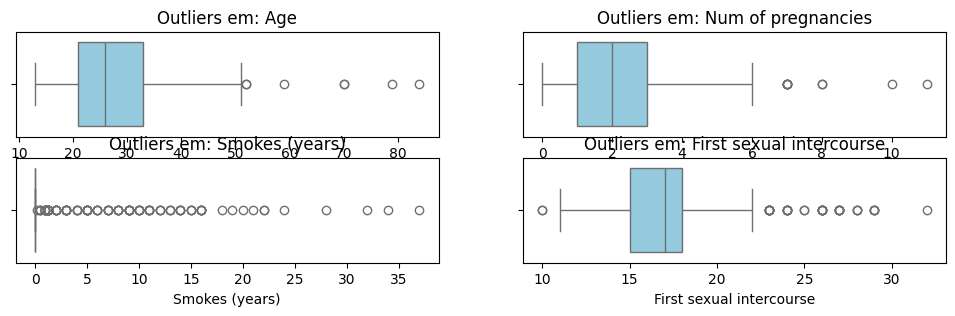

In [20]:
# Lista de colunas com dados interessantes e que podem variar muito
colunas_foco = ['Age', 'Num of pregnancies', 'Smokes (years)', 'First sexual intercourse']

# Criando os gráficos
plt.figure(figsize=(12, 3))

for i, coluna in enumerate(colunas_foco):
    plt.subplot(2, 2, i + 1) # Cria uma grade 2x2 de gráficos
    sns.boxplot(x=df_preenchido[coluna], color='skyblue')
    plt.title(f'Outliers em: {coluna}')
plt.show()

#Manterei os outlines e utilizarei RobustScaler

<h3><b>Gerando um novo arquivo CSV com os dados já tratados

In [21]:
def generation_csv_new(df_preenchido):
    df_preenchido.to_csv('dados_limpos.csv', index=False)
    print("New archive CSV, with data cleaning generate")

<h3>Create Pipeline</h3>

In [22]:
def pipeline_clean_date(df_raw):
    df = changed_question_values(df_raw)
    df = remove_missing_values(df)
    df = imput_missing_values(df)
    df = droping_duplicates(df)
    generation_csv_new(df)
    print(df.shape)
    return df

df = pipeline_clean_date(df_raw)

(858, 36)
Columns removed: 2
Rows removed: 98
Numbers of Duplicates Removed 19
New archive CSV, with data cleaning generate
(741, 34)
